In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [136]:
path = r"D:\AI\Artificial-Intelligence-Machine-Learning-and-Deep-Learning-Corvit-Peshawar-2026\Artificial-Inteligence-Machine-Learning-and-Deep-Learning-NAVTTC-Course-2026\week-06-regression-and-classification-ML\datasets\kc_house_data.csv"

df = pd.read_csv(path)
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [174]:
df.iloc[:, 1:].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           21613 non-null  object 
 1   price          21613 non-null  float64
 2   bedrooms       21613 non-null  int64  
 3   bathrooms      21613 non-null  float64
 4   sqft_living    21613 non-null  int64  
 5   sqft_lot       21613 non-null  int64  
 6   floors         21613 non-null  float64
 7   waterfront     21613 non-null  int64  
 8   view           21613 non-null  int64  
 9   condition      21613 non-null  int64  
 10  grade          21613 non-null  int64  
 11  sqft_above     21613 non-null  int64  
 12  sqft_basement  21613 non-null  int64  
 13  yr_built       21613 non-null  int64  
 14  yr_renovated   21613 non-null  int64  
 15  zipcode        21613 non-null  int64  
 16  lat            21613 non-null  float64
 17  long           21613 non-null  float64
 18  sqft_l

In [178]:
df.iloc[:, 2:].corr()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
price,1.000000,0.308350,0.525138,0.702035,0.089661,0.256794,0.266369,0.397293,0.036362,0.667434,0.605567,0.323816,0.054012,0.126434,-0.053203,0.307003,0.021626,0.585379,0.082447
bedrooms,0.308350,1.000000,0.515884,0.576671,0.031703,0.175429,-0.006582,0.079532,0.028472,0.356967,0.477600,0.303093,0.154178,0.018841,-0.152668,-0.008931,0.129473,0.391638,0.029244
bathrooms,0.525138,0.515884,1.000000,0.754665,0.087740,0.500653,0.063744,0.187737,-0.124982,0.664983,0.685342,0.283770,0.506019,0.050739,-0.203866,0.024573,0.223042,0.568634,0.087175
sqft_living,0.702035,0.576671,0.754665,1.000000,0.172826,0.353949,0.103818,0.284611,-0.058753,0.762704,0.876597,0.435043,0.318049,0.055363,-0.199430,0.052529,0.240223,0.756420,0.183286
sqft_lot,0.089661,0.031703,0.087740,0.172826,1.000000,-0.005201,0.021604,0.074710,-0.008958,0.113621,0.183512,0.015286,0.053080,0.007644,-0.129574,-0.085683,0.229521,0.144608,0.718557
floors,0.256794,0.175429,0.500653,0.353949,-0.005201,1.000000,0.023698,0.029444,-0.263768,0.458183,0.523885,-0.245705,0.489319,0.006338,-0.059121,0.049614,0.125419,0.279885,-0.011269
waterfront,0.266369,-0.006582,0.063744,0.103818,0.021604,0.023698,1.000000,0.401857,0.016653,0.082775,0.072075,0.080588,-0.026161,0.092885,0.030285,-0.014274,-0.041910,0.086463,0.030703
view,0.397293,0.079532,0.187737,0.284611,0.074710,0.029444,0.401857,1.000000,0.045990,0.251321,0.167649,0.276947,-0.053440,0.103917,0.084827,0.006157,-0.078400,0.280439,0.072575
condition,0.036362,0.028472,-0.124982,-0.058753,-0.008958,-0.263768,0.016653,0.045990,1.000000,-0.144674,-0.158214,0.174105,-0.361417,-0.060618,0.003026,-0.014941,-0.106500,-0.092824,-0.003406
grade,0.667434,0.356967,0.664983,0.762704,0.113621,0.458183,0.082775,0.251321,-0.144674,1.000000,0.755923,0.168392,0.446963,0.014414,-0.184862,0.114084,0.198372,0.713202,0.119248


In [137]:
df.shape

(21613, 21)

In [171]:
df.columns

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')

In [194]:
x = df[['bedrooms', 'bathrooms', 'sqft_living', 'floors', 'waterfront', 'view', 'grade', 'sqft_above', "sqft_basement",  "lat", 'long', 'sqft_living15']]
y = df['price']

In [195]:
x.head()

,bedrooms,bathrooms,sqft_living,floors,waterfront,view,grade,sqft_above,sqft_basement,lat,long,sqft_living15
0,3,1.00,1180,1.0,0,0,7,1180,0,47.5112,-122.257,1340
1,3,2.25,2570,2.0,0,0,7,2170,400,47.7210,-122.319,1690
2,2,1.00,770,1.0,0,0,6,770,0,47.7379,-122.233,2720
3,4,3.00,1960,1.0,0,0,7,1050,910,47.5208,-122.393,1360
4,3,2.00,1680,1.0,0,0,8,1680,0,47.6168,-122.045,1800


In [196]:
y.head()

0    221900.0
1    538000.0
2    180000.0
3    604000.0
4    510000.0
Name: price, dtype: float64

In [197]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   bedrooms       21613 non-null  int64  
 1   bathrooms      21613 non-null  float64
 2   sqft_living    21613 non-null  int64  
 3   floors         21613 non-null  float64
 4   waterfront     21613 non-null  int64  
 5   view           21613 non-null  int64  
 6   grade          21613 non-null  int64  
 7   sqft_above     21613 non-null  int64  
 8   sqft_basement  21613 non-null  int64  
 9   lat            21613 non-null  float64
 10  long           21613 non-null  float64
 11  sqft_living15  21613 non-null  int64  
dtypes: float64(4), int64(8)
memory usage: 2.0 MB


In [198]:
x.columns

Index(['bedrooms', 'bathrooms', 'sqft_living', 'floors', 'waterfront', 'view',
       'grade', 'sqft_above', 'sqft_basement', 'lat', 'long', 'sqft_living15'],
      dtype='object')

In [201]:
x.loc[:, 'bedrooms']

0        3
1        3
2        2
3        4
4        3
        ..
21608    3
21609    4
21610    2
21611    3
21612    2
Name: bedrooms, Length: 21613, dtype: int64

In [202]:
for column in x.columns:
    x.loc[:, column] = x.loc[:, column].astype(float)
    x.loc[:, column] = x.loc[:, column]/x.loc[:, column].max()

C:\Users\Abbas\AppData\Local\Temp\ipykernel_12464\413195314.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.09090909 0.09090909 0.06060606 ... 0.06060606 0.09090909 0.06060606]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  x.loc[:, column] = x.loc[:, column]/x.loc[:, column].max()
C:\Users\Abbas\AppData\Local\Temp\ipykernel_12464\413195314.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.08714919 0.18980798 0.05686854 ... 0.07533235 0.11816839 0.07533235]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  x.loc[:, column] = x.loc[:, column]/x.loc[:, column].max()
C:\Users\Abbas\AppData\Local\Temp\ipykernel_12464\413195314.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0. 0.

In [203]:
x

,bedrooms,bathrooms,sqft_living,floors,waterfront,view,grade,sqft_above,sqft_basement,lat,long,sqft_living15
0,0.090909,0.12500,0.087149,0.285714,0,0.0,0.538462,0.125399,0.000000,0.994424,1.007765,0.215781
1,0.090909,0.28125,0.189808,0.571429,0,0.0,0.538462,0.230606,0.082988,0.998815,1.008276,0.272142
2,0.060606,0.12500,0.056869,0.285714,0,0.0,0.461538,0.081828,0.000000,0.999169,1.007567,0.438003
3,0.121212,0.37500,0.144756,0.285714,0,0.0,0.538462,0.111583,0.188797,0.994625,1.008886,0.219002
4,0.090909,0.25000,0.124077,0.285714,0,0.0,0.615385,0.178533,0.000000,0.996634,1.006017,0.289855
...,...,...,...,...,...,...,...,...,...,...,...,...
21608,0.090909,0.31250,0.112999,0.857143,0,0.0,0.615385,0.162593,0.000000,0.998361,1.008499,0.246377
21609,0.121212,0.31250,0.170606,0.571429,0,0.0,0.615385,0.245484,0.000000,0.994414,1.008630,0.294686
21610,0.060606,0.09375,0.075332,0.571429,0,0.0,0.538462,0.108395,0.000000,0.996166,1.008111,0.164251
21611,0.090909,0.31250,0.118168,0.571429,0,0.0,0.615385,0.170032,0.000000,0.994912,1.006215,0.227053


Text(0, 0.5, 'price')

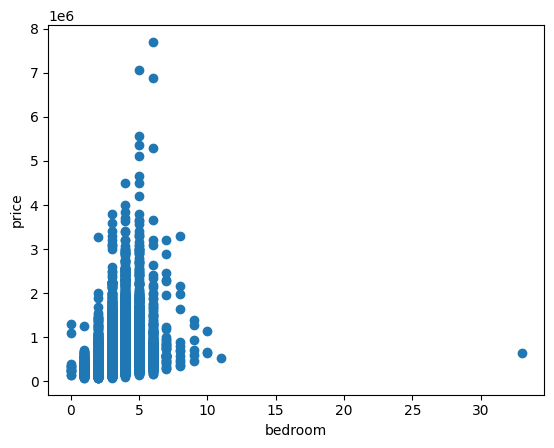

In [144]:
plt.scatter(x['bedrooms'], y)
plt.xlabel("bedroom")
plt.ylabel("price")

Text(0, 0.5, 'Price')

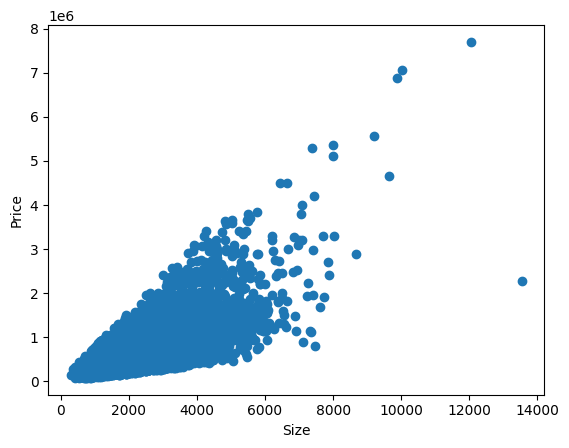

In [145]:
plt.scatter(x['sqft_living'], y)
plt.xlabel("Size")
plt.ylabel("Price")

In [207]:
x.shape[0]/100 * 80

17290.4

In [208]:
x_train = x.iloc[:17290, :]
x_test = x.iloc[17290:, :]

y_train = y.iloc[0:17290]
y_test = y.iloc[17290:]

In [209]:
x_train

,bedrooms,bathrooms,sqft_living,floors,waterfront,view,grade,sqft_above,sqft_basement,lat,long,sqft_living15
0,0.090909,0.12500,0.087149,0.285714,0,0.00,0.538462,0.125399,0.000000,0.994424,1.007765,0.215781
1,0.090909,0.28125,0.189808,0.571429,0,0.00,0.538462,0.230606,0.082988,0.998815,1.008276,0.272142
2,0.060606,0.12500,0.056869,0.285714,0,0.00,0.461538,0.081828,0.000000,0.999169,1.007567,0.438003
3,0.121212,0.37500,0.144756,0.285714,0,0.00,0.538462,0.111583,0.188797,0.994625,1.008886,0.219002
4,0.090909,0.25000,0.124077,0.285714,0,0.00,0.615385,0.178533,0.000000,0.996634,1.006017,0.289855
...,...,...,...,...,...,...,...,...,...,...,...,...
17285,0.121212,0.31250,0.182422,0.857143,0,0.00,0.615385,0.262487,0.000000,0.997884,1.008853,0.204509
17286,0.151515,0.31250,0.203840,0.285714,0,0.00,0.615385,0.170032,0.240664,0.998910,1.008095,0.074074
17287,0.090909,0.25000,0.187592,0.428571,0,0.75,0.615385,0.170032,0.195021,0.996224,1.008053,0.328502
17288,0.090909,0.53125,0.380355,0.714286,0,0.50,0.846154,0.443146,0.203320,0.996886,1.007971,0.687601


In [227]:
x_train = np.array(x_train)
x_test = np.array(x_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

In [228]:
x_train.dtype

dtype('float64')

In [229]:
x_train[0:3]

array([[0.09090909, 0.125     , 0.08714919, 0.28571429, 0.        ,
        0.        , 0.53846154, 0.12539851, 0.        , 0.99442417,
        1.00776491, 0.215781  ],
       [0.09090909, 0.28125   , 0.18980798, 0.57142857, 0.        ,
        0.        , 0.53846154, 0.23060574, 0.08298755, 0.99881534,
        1.00827598, 0.27214171],
       [0.06060606, 0.125     , 0.05686854, 0.28571429, 0.        ,
        0.        , 0.46153846, 0.08182784, 0.        , 0.99916907,
        1.00756708, 0.43800322]])

In [230]:
x_train.shape

(17290, 12)

In [257]:
def predict(x, w, b):
    y_hat = np.dot(x, w) + b
    return y_hat

In [232]:
def cost(x, y, w, b):
    y_hat = predict(x, w, b)
    error = y_hat - y
    c = np.sum(error**2)/(2*len(x))
    return c

In [262]:
def gradient(x, y, w, b, alpha):
    y_hat = predict(x, w, b)

    gw = np.mean((y_hat - y).reshape(y.shape[0], 1)*x)
    gb = np.mean(y_hat - y)

    w = w - alpha * gw
    b = b - alpha * gb

    return w, b


In [300]:
w = np.array([0,0,0,0,0,0,0,0,0,0,0,0])
b = np.random.rand()

print("W : ", w.shape)
print("b : ", b)

W :  (12,)
b :  0.16388364350455253


In [301]:
epochs = 100000

history = []

for i in range(1, epochs+1):
    w, b = gradient(x_train, y_train, w, b, 0.1)

    loss = cost(x_train, y_train, w, b)
    history.append(loss)

    print(f"Epoch : {i},  w1 : {np.round(w, 2)},  b : {round(b, 2)},    cost : {round(loss, 2)}")

Epoch : 1,  w1 : [19806.55 19806.55 19806.55 19806.55 19806.55 19806.55 19806.55 19806.55
 19806.55 19806.55 19806.55 19806.55],  b : 53324.9,    cost : 142859229506.14
Epoch : 2,  w1 : [34872.71 34872.71 34872.71 34872.71 34872.71 34872.71 34872.71 34872.71
 34872.71 34872.71 34872.71 34872.71],  b : 93110.13,    cost : 105060483981.21
Epoch : 3,  w1 : [46359.86 46359.86 46359.86 46359.86 46359.86 46359.86 46359.86 46359.86
 46359.86 46359.86 46359.86 46359.86],  b : 122674.04,    cost : 83488747433.6
Epoch : 4,  w1 : [55144.79 55144.79 55144.79 55144.79 55144.79 55144.79 55144.79 55144.79
 55144.79 55144.79 55144.79 55144.79],  b : 144521.76,    cost : 71166233835.03
Epoch : 5,  w1 : [61889.46 61889.46 61889.46 61889.46 61889.46 61889.46 61889.46 61889.46
 61889.46 61889.46 61889.46 61889.46],  b : 160544.59,    cost : 64115710192.96
Epoch : 6,  w1 : [67093.65 67093.65 67093.65 67093.65 67093.65 67093.65 67093.65 67093.65
 67093.65 67093.65 67093.65 67093.65],  b : 172170.42,    cost

KeyboardInterrupt: 

In [302]:
len(history)

29293

In [303]:
ep = list(range(1, 29293+1))

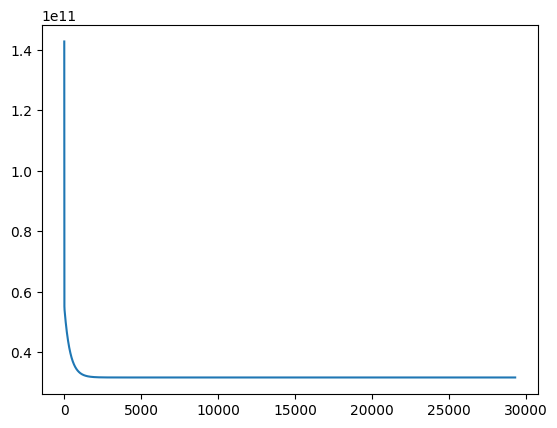

In [304]:

plt.plot(ep, history)

In [305]:
w

array([423278.3481789, 423278.3481789, 423278.3481789, 423278.3481789,
       423278.3481789, 423278.3481789, 423278.3481789, 423278.3481789,
       423278.3481789, 423278.3481789, 423278.3481789, 423278.3481789])

In [ ]:
y_hat = predict(x_test, w, b)

In [307]:
y_test

array([380000., 624900., 379770., ..., 402101., 400000., 325000.])

In [320]:
y_hat = y_hat.reshape(4323, 1)

In [322]:
y_test = y_test.reshape(4323, 1)

In [324]:
pd.DataFrame(np.concatenate((y_hat, y_test), axis=1))

,0,1
0,535556.974462,380000.0
1,535556.974462,624900.0
2,524912.899844,379770.0
3,328094.446803,340000.0
4,734033.163858,515500.0
...,...,...
4318,643796.558880,360000.0
4319,613989.292067,400000.0
4320,310141.964381,402101.0
4321,517591.115138,400000.0
